# Handwriting Data Merging UCI and PaHaW Datasets

This notebook explores the pipeline to merge the two datasets



## UCI dataset
The UCI dataset has
0: Static Spiral Test ( Draw on the given spiral pattern)
1: Dynamic Spiral Test ( Spiral pattern will blink in a certain time, 
so subjects need to continue on their draw)
2: Circular Motion Test (Subjectd draw circles around the red point)

I had to only make sure we were using those with testID = 0 because only the 
static spiral test is comparable to our PaHaw dataset.

One of the data records had testID = 2, so I deleted that record


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 1. Configure Data Paths

In [2]:
import os
from pathlib import Path

# Current notebook location
CURRENT_DIR = Path.cwd()
print("Current directory:", CURRENT_DIR)

# You are already inside the handwriting folder
HANDWRITING_DIR = CURRENT_DIR
print("Handwriting directory:", HANDWRITING_DIR)

# Dataset folders
UCI_DIR = HANDWRITING_DIR / "UCI Dataset" / "new_dataset" / "parkinson"
PAHAW_DIR = HANDWRITING_DIR / "PaHaw Dataset" / "PaHaW_all"

# Processed folder
PROCESSED_DIR = HANDWRITING_DIR / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Optional outputs folder
OUTPUT_DIR = HANDWRITING_DIR.parent.parent / "outputs" / "handwriting_eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("\nPaths:")
print("UCI_DIR:", UCI_DIR)
print("PAHAW_DIR:", PAHAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

print("\nUCI files:")
print(list(UCI_DIR.glob("*"))[:5])

print("\nPaHaW files:")
print(list(PAHAW_DIR.glob("*"))[:5])

Current directory: /ocean/projects/med260006p/mkhelgi/biomedAI/project/data/handwriting
Handwriting directory: /ocean/projects/med260006p/mkhelgi/biomedAI/project/data/handwriting

Paths:
UCI_DIR: /ocean/projects/med260006p/mkhelgi/biomedAI/project/data/handwriting/UCI Dataset/new_dataset/parkinson
PAHAW_DIR: /ocean/projects/med260006p/mkhelgi/biomedAI/project/data/handwriting/PaHaw Dataset/PaHaW_all
PROCESSED_DIR: /ocean/projects/med260006p/mkhelgi/biomedAI/project/data/handwriting/processed
OUTPUT_DIR: /ocean/projects/med260006p/mkhelgi/biomedAI/project/outputs/handwriting_eda

UCI files:
[PosixPath('/ocean/projects/med260006p/mkhelgi/biomedAI/project/data/handwriting/UCI Dataset/new_dataset/parkinson/H_P000-0036.txt'), PosixPath('/ocean/projects/med260006p/mkhelgi/biomedAI/project/data/handwriting/UCI Dataset/new_dataset/parkinson/H_P000-0004.txt'), PosixPath('/ocean/projects/med260006p/mkhelgi/biomedAI/project/data/handwriting/UCI Dataset/new_dataset/parkinson/P_09100005.txt'), Pos

In [3]:
# Count number of files
print("Number of UCI .txt files:", len(list(UCI_DIR.rglob("*.txt"))))
print("Number of PaHaW .svc files:", len(list(PAHAW_DIR.rglob("*.svc"))))

Number of UCI .txt files: 76
Number of PaHaW .svc files: 72


## 2. Load one file from each dataset, inspect them, and standardize the format

In [4]:
uci_example = next(UCI_DIR.rglob("*.txt"), None)
pahaw_example = next(PAHAW_DIR.rglob("*.svc"), None)

print("UCI example:", uci_example)
print("PaHaW example:", pahaw_example)

UCI example: /ocean/projects/med260006p/mkhelgi/biomedAI/project/data/handwriting/UCI Dataset/new_dataset/parkinson/H_P000-0036.txt
PaHaW example: /ocean/projects/med260006p/mkhelgi/biomedAI/project/data/handwriting/PaHaw Dataset/PaHaW_all/00031__1_1.svc


In [5]:
import pandas as pd
from pathlib import Path

def load_uci_preview(file_path):
    file_path = Path(file_path)
    file_id = file_path.stem   # e.g. C_0001

    df = pd.read_csv(file_path, sep=";", header=None)

    df.columns = [
        "X",
        "Y",
        "Z",
        "Pressure",
        "GripAngle",
        "Timestamp",
        "TestID"
    ]

    # ✅ add IDs
    df["subject_id"] = file_id
    df["drawing_id"] = file_id
    df["dataset"] = "UCI"

    return df


def load_pahaw_preview(file_path):
    file_path = Path(file_path)
    file_id = file_path.stem   # e.g. 00031__1_1

    df = pd.read_csv(
        file_path,
        sep=r"\s+",
        skiprows=1,
        header=None,
        engine="python"
    )

    df.columns = ["y", "x", "timestamp", "button", "azimuth", "altitude", "pressure"]

    # ✅ add IDs
    df["subject_id"] = file_id
    df["drawing_id"] = file_id
    df["dataset"] = "PaHaW"

    return df

In [6]:

uci_df = load_uci_preview(uci_example)
pahaw_df = load_pahaw_preview(pahaw_example)

print("UCI preview:")
display(uci_df.head())
print("UCI shape:", uci_df.shape)

print("\nPaHaW preview:")
display(pahaw_df.head())
print("PaHaW shape:", pahaw_df.shape)

UCI preview:


,X,Y,Z,Pressure,GripAngle,Timestamp,TestID,subject_id,drawing_id,dataset
0,209,201,0,1,710,2419243170,0,H_P000-0036,H_P000-0036,UCI
1,209,201,0,3,710,2419243177,0,H_P000-0036,H_P000-0036,UCI
2,210,201,0,3,710,2419243184,0,H_P000-0036,H_P000-0036,UCI
3,210,201,0,3,710,2419243191,0,H_P000-0036,H_P000-0036,UCI
4,210,201,0,4,710,2419243198,0,H_P000-0036,H_P000-0036,UCI


UCI shape: (8051, 10)

PaHaW preview:


,y,x,timestamp,button,azimuth,altitude,pressure,subject_id,drawing_id,dataset
0,4020,2702,7178717,1,3193,554,60,00031__1_1,00031__1_1,PaHaW
1,4020,2702,7178724,1,3193,554,92,00031__1_1,00031__1_1,PaHaW
2,4020,2702,7178732,1,3193,554,120,00031__1_1,00031__1_1,PaHaW
3,4020,2702,7178739,1,3193,554,146,00031__1_1,00031__1_1,PaHaW
4,4020,2702,7178747,1,3193,554,174,00031__1_1,00031__1_1,PaHaW


PaHaW shape: (2714, 10)


In [7]:
# Sanity check: plot the spirals to confirm they look correct

import matplotlib.pyplot as plt

def plot_uci_spiral(df, title="UCI Spiral"):

    df = df[df["TestID"] == 0]

    plt.figure(figsize=(5,5))
    plt.plot(df["X"], df["Y"])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.axis("equal")
    plt.show()


def plot_pahaw_spiral(df, title="PaHaW Spiral"):

    plt.figure(figsize=(5,5))
    plt.plot(df["x"], df["y"])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.axis("equal")
    plt.show()

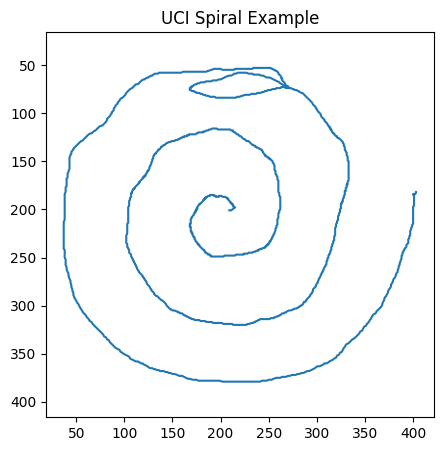

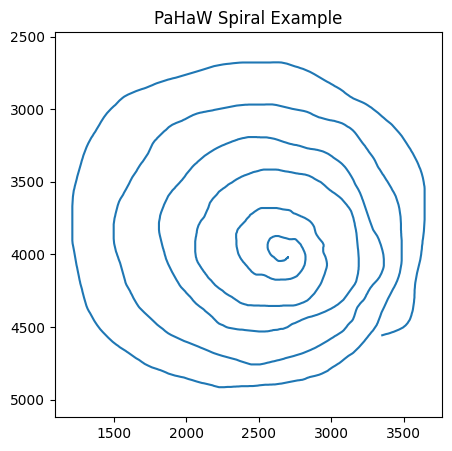

In [8]:
plot_uci_spiral(uci_df, "UCI Spiral Example")
plot_pahaw_spiral(pahaw_df, "PaHaW Spiral Example")

In [9]:
def standardize_uci(df, file_name):
    df = df.copy()

    df = df[df["TestID"] == 0]

    df = df.rename(columns={
        "X": "x",
        "Y": "y",
        "Timestamp": "timestamp",
        "Pressure": "pressure"
    })

    cols = ["x", "y", "timestamp", "pressure", "subject_id", "drawing_id"]
    df = df[cols]

    df["dataset"] = "UCI"
    return df


def standardize_pahaw(df, file_path):
    df = df.copy()

    df = df.rename(columns={
        "x": "x",
        "y": "y",
        "timestamp": "timestamp",
        "pressure": "pressure"
    })

    cols = ["x", "y", "timestamp", "pressure", "subject_id", "drawing_id"]
    df = df[cols]

    df["dataset"] = "PaHaW"
    return df

In [10]:
# Normalize each drawing
def normalize_drawing(df):

    df = df.copy()

    # normalize X
    df["x"] = (df["x"] - df["x"].min()) / (df["x"].max() - df["x"].min())

    # normalize Y
    df["y"] = (df["y"] - df["y"].min()) / (df["y"].max() - df["y"].min())

    # normalize pressure
    df["pressure"] = (df["pressure"] - df["pressure"].min()) / (
        df["pressure"].max() - df["pressure"].min()
    )

    # reset timestamp so drawing starts at 0
    df["timestamp"] = df["timestamp"] - df["timestamp"].min()

    return df

In [11]:
uci_std = standardize_uci(uci_df, uci_example.stem)
pahaw_std = standardize_pahaw(pahaw_df, pahaw_example)

uci_norm = normalize_drawing(uci_std)
pahaw_norm = normalize_drawing(pahaw_std)

display(uci_norm.head())
display(pahaw_norm.head())


,x,y,timestamp,pressure,subject_id,drawing_id,dataset
0,0.469945,0.453988,0,0.000000,H_P000-0036,H_P000-0036,UCI
1,0.469945,0.453988,7,0.003241,H_P000-0036,H_P000-0036,UCI
2,0.472678,0.453988,14,0.003241,H_P000-0036,H_P000-0036,UCI
3,0.472678,0.453988,21,0.003241,H_P000-0036,H_P000-0036,UCI
4,0.472678,0.453988,28,0.004862,H_P000-0036,H_P000-0036,UCI


,x,y,timestamp,pressure,subject_id,drawing_id,dataset
0,0.612026,0.600268,0,0.000000,00031__1_1,00031__1_1,PaHaW
1,0.612026,0.600268,7,0.029012,00031__1_1,00031__1_1,PaHaW
2,0.612026,0.600268,15,0.054397,00031__1_1,00031__1_1,PaHaW
3,0.612026,0.600268,22,0.077969,00031__1_1,00031__1_1,PaHaW
4,0.612026,0.600268,30,0.103354,00031__1_1,00031__1_1,PaHaW


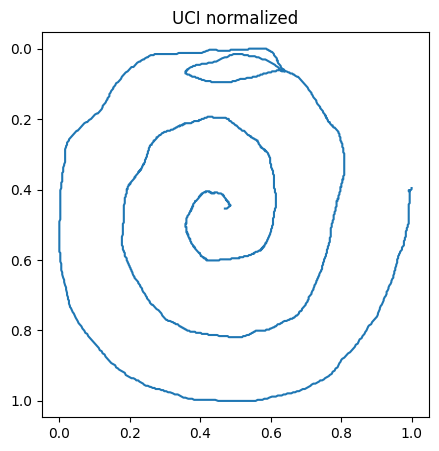

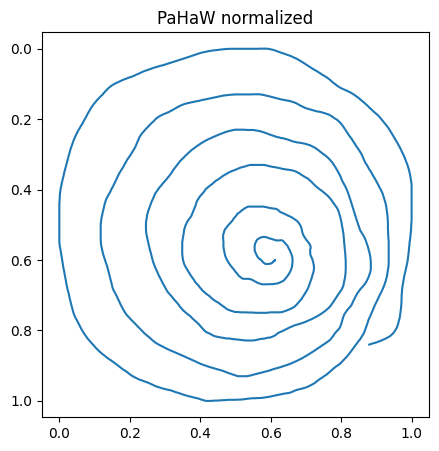

In [12]:
def plot_normalized(df, title):

    plt.figure(figsize=(5,5))
    plt.plot(df["x"], df["y"])
    plt.gca().invert_yaxis()
    plt.title(title)
    plt.axis("equal")
    plt.show()


plot_normalized(uci_norm, "UCI normalized")
plot_normalized(pahaw_norm, "PaHaW normalized")

In [13]:
import numpy as np

def resample_drawing(df, step_ms=10):

    df = df.sort_values("timestamp").copy()

    t = df["timestamp"].values
    x = df["x"].values
    y = df["y"].values
    p = df["pressure"].values

    if len(df) < 2:
        return df

    new_t = np.arange(t.min(), t.max(), step_ms)

    new_x = np.interp(new_t, t, x)
    new_y = np.interp(new_t, t, y)
    new_p = np.interp(new_t, t, p)

    new_df = pd.DataFrame({
        "timestamp": new_t,
        "x": new_x,
        "y": new_y,
        "pressure": new_p
    })

    # keep metadata
    for col in ["subject_id", "drawing_id", "dataset"]:
        new_df[col] = df.iloc[0][col]

    return new_df

In [14]:
uci_resampled = resample_drawing(uci_norm)
pahaw_resampled = resample_drawing(pahaw_norm)

print("UCI resampled shape:", uci_resampled.shape)
print("PaHaW resampled shape:", pahaw_resampled.shape)

display(uci_resampled.head())
display(pahaw_resampled.head())

UCI resampled shape: (1369, 7)
PaHaW resampled shape: (2043, 7)


,timestamp,x,y,pressure,subject_id,drawing_id,dataset
0,0,0.469945,0.453988,0.000000,H_P000-0036,H_P000-0036,UCI
1,10,0.471116,0.453988,0.003241,H_P000-0036,H_P000-0036,UCI
2,20,0.472678,0.453988,0.003241,H_P000-0036,H_P000-0036,UCI
3,30,0.472678,0.453988,0.005788,H_P000-0036,H_P000-0036,UCI
4,40,0.472678,0.453988,0.005788,H_P000-0036,H_P000-0036,UCI


,timestamp,x,y,pressure,subject_id,drawing_id,dataset
0,0,0.612026,0.600268,0.000000,00031__1_1,00031__1_1,PaHaW
1,10,0.612026,0.600268,0.038531,00031__1_1,00031__1_1,PaHaW
2,20,0.612026,0.600268,0.071234,00031__1_1,00031__1_1,PaHaW
3,30,0.612026,0.600268,0.103354,00031__1_1,00031__1_1,PaHaW
4,40,0.612026,0.599821,0.133726,00031__1_1,00031__1_1,PaHaW


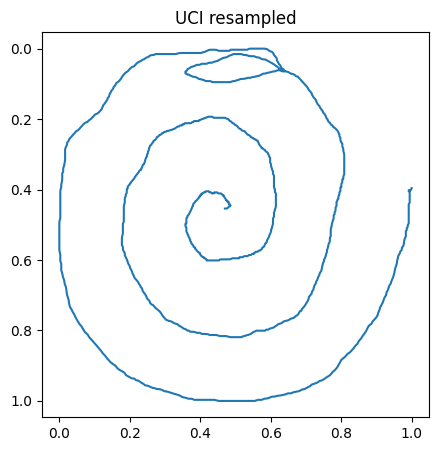

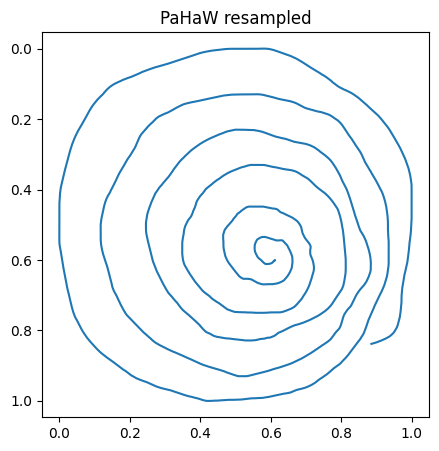

In [15]:
plot_normalized(uci_resampled, "UCI resampled")
plot_normalized(pahaw_resampled, "PaHaW resampled")

## 3. Load all the data

In [16]:
def load_all_uci(uci_dir):

    records = []

    for file_path in uci_dir.rglob("*.txt"):

        df = load_uci_preview(file_path)
        df = standardize_uci(df, file_path.stem)

        df = normalize_drawing(df)
        df = resample_drawing(df)

        records.append(df)

    return pd.concat(records, ignore_index=True)

def load_all_pahaw(pahaw_dir):

    records = []

    for file_path in pahaw_dir.rglob("*.svc"):

        df = load_pahaw_preview(file_path)
        df = standardize_pahaw(df, file_path)

        df = normalize_drawing(df)
        df = resample_drawing(df)

        records.append(df)

    return pd.concat(records, ignore_index=True)

In [17]:
uci_all = load_all_uci(UCI_DIR)
pahaw_all = load_all_pahaw(PAHAW_DIR)

print("UCI dataset shape:", uci_all.shape)
print("PaHaW dataset shape:", pahaw_all.shape)

display(uci_all.head())
display(pahaw_all.head())

UCI dataset shape: (177145, 7)
PaHaW dataset shape: (158345, 7)


,timestamp,x,y,pressure,subject_id,drawing_id,dataset
0,0,0.469945,0.453988,0.000000,H_P000-0036,H_P000-0036,UCI
1,10,0.471116,0.453988,0.003241,H_P000-0036,H_P000-0036,UCI
2,20,0.472678,0.453988,0.003241,H_P000-0036,H_P000-0036,UCI
3,30,0.472678,0.453988,0.005788,H_P000-0036,H_P000-0036,UCI
4,40,0.472678,0.453988,0.005788,H_P000-0036,H_P000-0036,UCI


,timestamp,x,y,pressure,subject_id,drawing_id,dataset
0,0,0.612026,0.600268,0.000000,00031__1_1,00031__1_1,PaHaW
1,10,0.612026,0.600268,0.038531,00031__1_1,00031__1_1,PaHaW
2,20,0.612026,0.600268,0.071234,00031__1_1,00031__1_1,PaHaW
3,30,0.612026,0.600268,0.103354,00031__1_1,00031__1_1,PaHaW
4,40,0.612026,0.599821,0.133726,00031__1_1,00031__1_1,PaHaW


In [18]:
merged = pd.concat([uci_all, pahaw_all], ignore_index=True)

print("Merged dataset shape:", merged.shape)

print(merged["dataset"].value_counts())

Merged dataset shape: (335490, 7)
dataset
UCI      177145
PaHaW    158345
Name: count, dtype: int64


In [19]:
merged_path = PROCESSED_DIR / "merged_handwriting_timeseries.csv"

merged.to_csv(merged_path, index=False)

print("Saved dataset to:", merged_path)

Saved dataset to: /ocean/projects/med260006p/mkhelgi/biomedAI/project/data/handwriting/processed/merged_handwriting_timeseries.csv


In [20]:
merged = merged[
    ["subject_id", "drawing_id", "dataset", "timestamp", "x", "y", "pressure"]
]
merged_path = PROCESSED_DIR / "merged_handwriting_timeseries.csv"
merged.to_csv(merged_path, index=False)

In [21]:
merged.head()

,subject_id,drawing_id,dataset,timestamp,x,y,pressure
0,H_P000-0036,H_P000-0036,UCI,0,0.469945,0.453988,0.000000
1,H_P000-0036,H_P000-0036,UCI,10,0.471116,0.453988,0.003241
2,H_P000-0036,H_P000-0036,UCI,20,0.472678,0.453988,0.003241
3,H_P000-0036,H_P000-0036,UCI,30,0.472678,0.453988,0.005788
4,H_P000-0036,H_P000-0036,UCI,40,0.472678,0.453988,0.005788


## 4. EDA Analysis

In [22]:
print("Total rows:", len(merged))
print("Columns:", merged.columns)

print("\nDatasets:")
print(merged["dataset"].value_counts())

print("\nNumber of drawings:")
print(merged["drawing_id"].nunique())

print("\nDrawings per dataset:")
print(merged.groupby("dataset")["drawing_id"].nunique())

Total rows: 335490
Columns: Index(['subject_id', 'drawing_id', 'dataset', 'timestamp', 'x', 'y',
       'pressure'],
      dtype='object')

Datasets:
dataset
UCI      177145
PaHaW    158345
Name: count, dtype: int64

Number of drawings:
148

Drawings per dataset:
dataset
PaHaW    72
UCI      76
Name: drawing_id, dtype: int64


In [23]:
print("Dataset shape:", merged.shape)

print("\nColumns:")
print(merged.columns)

print("\nDatasets:")
print(merged["dataset"].value_counts())

print("\nUnique drawings:")
print(merged["drawing_id"].nunique())

print("\nUnique subjects:")
print(merged["subject_id"].nunique())

Dataset shape: (335490, 7)

Columns:
Index(['subject_id', 'drawing_id', 'dataset', 'timestamp', 'x', 'y',
       'pressure'],
      dtype='object')

Datasets:
dataset
UCI      177145
PaHaW    158345
Name: count, dtype: int64

Unique drawings:
148

Unique subjects:
148


In [24]:
samples_per_drawing = merged.groupby("drawing_id").size()

print(samples_per_drawing.describe())

count      148.000000
mean      2266.824324
std       1736.943103
min        370.000000
25%       1273.250000
50%       1810.500000
75%       2677.250000
max      12310.000000
dtype: float64


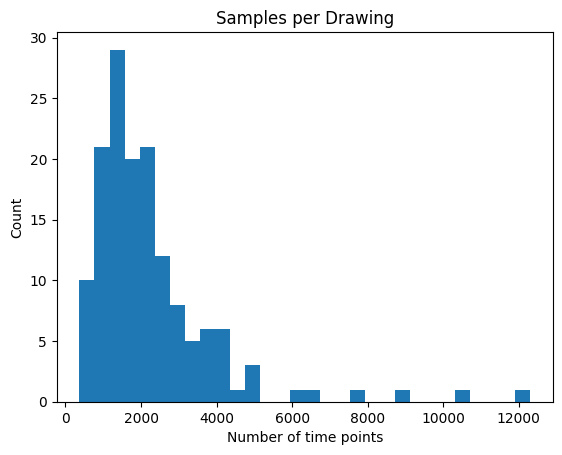

In [25]:
import matplotlib.pyplot as plt

plt.hist(samples_per_drawing, bins=30)
plt.title("Samples per Drawing")
plt.xlabel("Number of time points")
plt.ylabel("Count")
plt.show()

In [26]:
duration = merged.groupby("drawing_id")["timestamp"].max()

print(duration.describe())

count       148.000000
mean      22658.243243
std       17369.431030
min        3690.000000
25%       12722.500000
50%       18095.000000
75%       26762.500000
max      123090.000000
Name: timestamp, dtype: float64


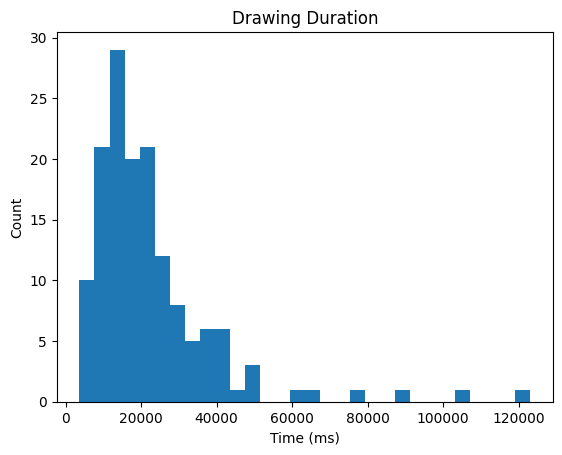

In [27]:
plt.hist(duration, bins=30)
plt.title("Drawing Duration")
plt.xlabel("Time (ms)")
plt.ylabel("Count")
plt.show()

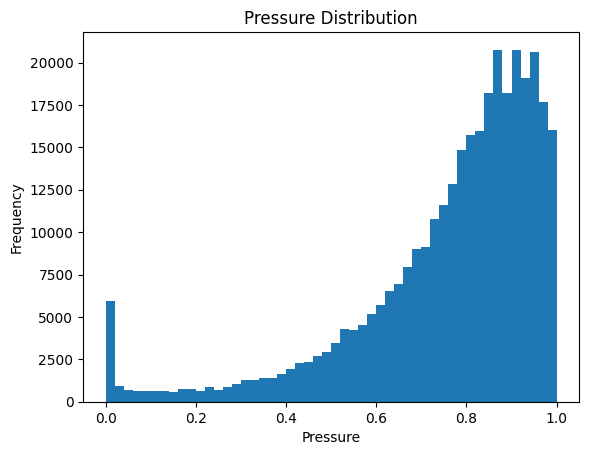

In [28]:
plt.hist(merged["pressure"], bins=50)
plt.title("Pressure Distribution")
plt.xlabel("Pressure")
plt.ylabel("Frequency")
plt.show()

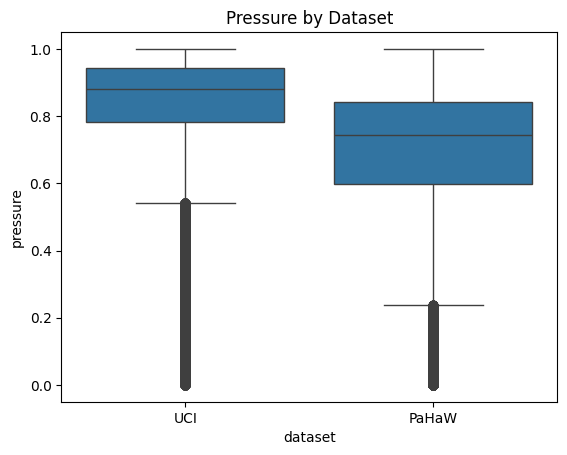

In [29]:
import seaborn as sns

sns.boxplot(data=merged, x="dataset", y="pressure")
plt.title("Pressure by Dataset")
plt.show()

In [30]:
import numpy as np

merged = merged.sort_values(["drawing_id","timestamp"])

merged["dx"] = merged.groupby("drawing_id")["x"].diff()
merged["dy"] = merged.groupby("drawing_id")["y"].diff()
merged["dt"] = merged.groupby("drawing_id")["timestamp"].diff()

merged["velocity"] = np.sqrt(merged["dx"]**2 + merged["dy"]**2) / merged["dt"]

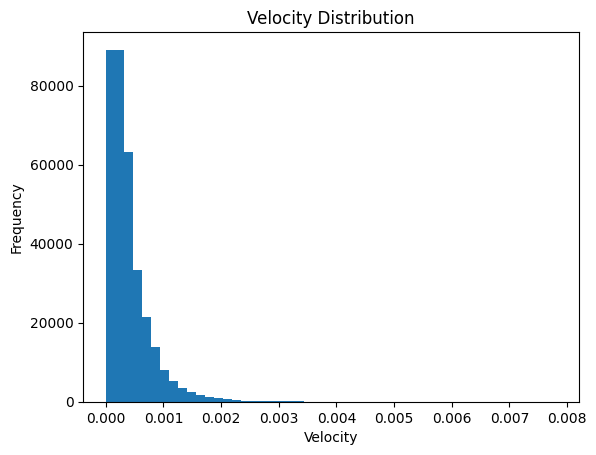

In [31]:
plt.hist(merged["velocity"].dropna(), bins=50)
plt.title("Velocity Distribution")
plt.xlabel("Velocity")
plt.ylabel("Frequency")
plt.show()

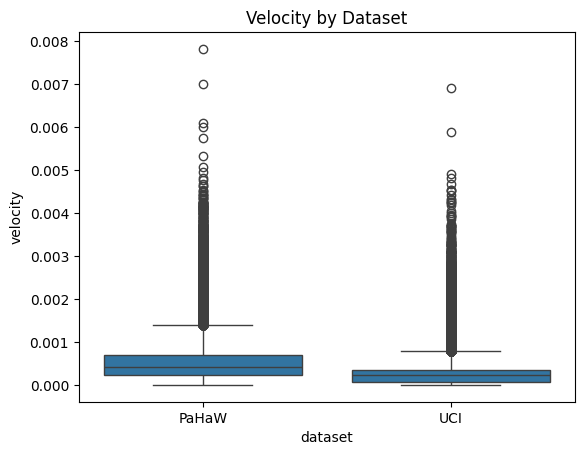

In [32]:
sns.boxplot(data=merged, x="dataset", y="velocity")
plt.title("Velocity by Dataset")
plt.show()

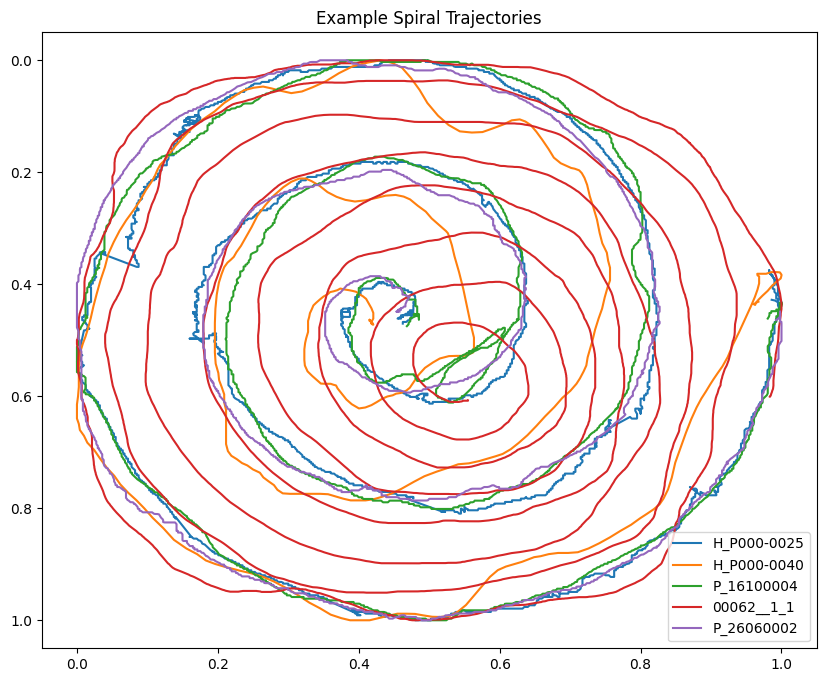

In [33]:
sample_drawings = merged["drawing_id"].sample(5).unique()

plt.figure(figsize=(10,8))

for d in sample_drawings:
    
    df = merged[merged["drawing_id"] == d]
    
    plt.plot(df["x"], df["y"], label=d)

plt.gca().invert_yaxis()
plt.title("Example Spiral Trajectories")
plt.legend()
plt.show()

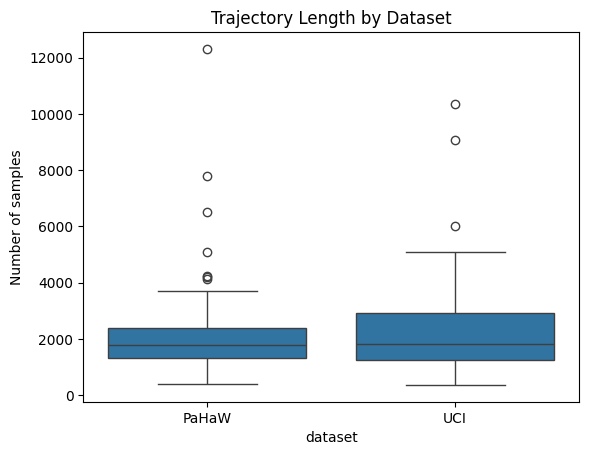

In [34]:
samples_dataset = merged.groupby(["dataset","drawing_id"]).size()

sns.boxplot(x=samples_dataset.index.get_level_values(0),
            y=samples_dataset.values)

plt.title("Trajectory Length by Dataset")
plt.ylabel("Number of samples")
plt.show()

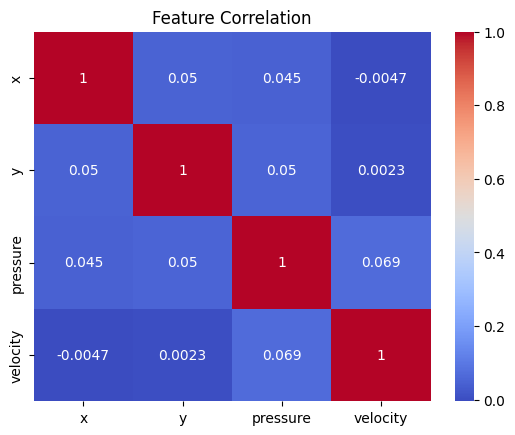

In [35]:
corr = merged[["x","y","pressure","velocity"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

## Interpretation
Most spiral drawings lasted between approximately 10 and 25 seconds. A small number of outliers extend beyond 60 seconds, reaching up to approximately 120 seconds. These longer recordings likely reflect differences in experimental protocols or drawing speeds across datasets.

The pressure distribution shows a strong concentration near zero, representing moments when the pen is lifted or barely contacting the tablet surface. Most active drawing pressure values fall between 0.6 and 1.0 after normalization, indicating consistent stylus contact during drawing movements.

Pressure distributions differ slightly between datasets, likely due to differences in digitizing tablet hardware and pressure sensor calibration. Despite normalization, PaHaW recordings show a slightly wider pressure variability compared to UCI.

The velocity distribution is highly right-skewed, with most movements occurring at relatively low speeds and a small number of rapid movements producing higher velocity values. This pattern is typical in handwriting trajectories where fine motor adjustments occur frequently.

Visual inspection of spiral trajectories shows consistent spiral structures across subjects, with variability in smoothness and curvature. These variations may reflect differences in motor control and tremor patterns across individuals.

PaHaW recordings tend to contain more time samples than UCI recordings, suggesting longer drawing durations or higher sampling density in the PaHaW dataset.

Correlation analysis reveals minimal linear relationships between spatial coordinates, pressure, and velocity features. This suggests that these variables capture distinct aspects of handwriting dynamics and may provide complementary information for downstream modeling.


## 5. Data Cleaning

In [36]:
merged.isna().sum()

subject_id      0
drawing_id      0
dataset         0
timestamp       0
x               0
y               0
pressure        0
dx            148
dy            148
dt            148
velocity      148
dtype: int64

In [37]:
print("After drop, rows:", len(merged))
# 1. Check duplicates
print("Duplicate rows (exact full-row):", merged.duplicated().sum())

After drop, rows: 335490
Duplicate rows (exact full-row): 0


In [38]:
# 2. Drop full-row duplicates
merged = merged.drop_duplicates().reset_index(drop=True)
print("After drop, rows:", len(merged))

After drop, rows: 335490


In [39]:
print("Before dropping timestamp repeats, rows:", len(merged))
# 3. If you want to drop repeated timestamps inside each drawing (same drawing_id+timestamp)
dup_ts = merged.duplicated(subset=["drawing_id", "timestamp"])
print("Duplicate (drawing_id,timestamp):", dup_ts.sum())




Before dropping timestamp repeats, rows: 335490


Duplicate (drawing_id,timestamp): 0


In [40]:

merged = merged[~dup_ts].reset_index(drop=True)
print("After dropping timestamp repeats, rows:", len(merged))

After dropping timestamp repeats, rows: 335490


In [41]:
# 4. Optional: ensure monotonic timestamp per drawing
bad = merged.groupby("drawing_id")["timestamp"].apply(lambda s: (s.diff().fillna(0) < 0).any())
print("Drawings with non-monotonic timestamp:", bad.sum())

Drawings with non-monotonic timestamp: 0


In [42]:
def quality_check(df, min_points=50):
    if len(df) < min_points:
        return False
    
    if df["x"].isna().any() or df["y"].isna().any():
        return False
    
    x_range = df["x"].max() - df["x"].min()
    y_range = df["y"].max() - df["y"].min()
    
    if x_range == 0 or y_range == 0:
        return False
    
    return True

In [43]:
print("Rows:", len(merged))
print("Unique drawings:", merged["drawing_id"].nunique())

Rows: 335490
Unique drawings: 148


In [44]:
clean_drawings = []
bad_drawings = []

print("size = ", merged.size)

for drawing_id, group in merged.groupby("drawing_id"):
    if quality_check(group):
        clean_drawings.append(group)
    else:
        bad_drawings.append(drawing_id)

final_df = pd.concat(clean_drawings, ignore_index=True)
print("Removed drawings:", bad_drawings)

size =  3690390
Removed drawings: []


## 6. Feature Extraction


In [45]:
def extract_summary_features(df):
    df = df.copy()

    # velocity
    df["vx"] = df["x"].diff()
    df["vy"] = df["y"].diff()
    df["speed"] = (df["vx"]**2 + df["vy"]**2)**0.5

    features = {
        "mean_speed": df["speed"].mean(),
        "std_speed": df["speed"].std(),
        "max_speed": df["speed"].max(),
        "path_length": df["speed"].sum(),
        "pressure_mean": df["pressure"].mean(),
        "pressure_std": df["pressure"].std(),
        "num_points": len(df)
    }

    return pd.Series(features)

In [46]:
feature_rows = []

for drawing_id, group in final_df.groupby("drawing_id"):
    feat = extract_summary_features(group)
    feat["drawing_id"] = drawing_id
    feature_rows.append(feat)

summary_df = pd.DataFrame(feature_rows)

In [47]:
summary_df.head()

,mean_speed,std_speed,max_speed,path_length,pressure_mean,pressure_std,num_points,drawing_id
0,0.006676,0.002234,0.012407,8.878561,0.682830,0.165367,1331.0,00001__1_1
1,0.006513,0.002831,0.012230,11.821008,0.701556,0.177101,1816.0,00002__1_1
2,0.006537,0.002778,0.013726,10.164609,0.771711,0.140597,1556.0,00003__1_1
3,0.005436,0.006274,0.078169,11.954190,0.535229,0.301377,2200.0,00004__1_1
4,0.001622,0.000806,0.006434,19.970112,0.814182,0.089330,12310.0,00005__1_1


In [48]:
summary_df

,mean_speed,std_speed,max_speed,path_length,pressure_mean,pressure_std,num_points,drawing_id
0,0.006676,0.002234,0.012407,8.878561,0.682830,0.165367,1331.0,00001__1_1
1,0.006513,0.002831,0.012230,11.821008,0.701556,0.177101,1816.0,00002__1_1
2,0.006537,0.002778,0.013726,10.164609,0.771711,0.140597,1556.0,00003__1_1
3,0.005436,0.006274,0.078169,11.954190,0.535229,0.301377,2200.0,00004__1_1
4,0.001622,0.000806,0.006434,19.970112,0.814182,0.089330,12310.0,00005__1_1
...,...,...,...,...,...,...,...,...
143,0.002086,0.001443,0.008829,5.851644,0.747239,0.211984,2806.0,P_26060007
144,0.002130,0.001577,0.007071,5.953133,0.810753,0.166891,2796.0,P_27110001
145,0.000794,0.001141,0.006466,7.193665,0.792292,0.206836,9059.0,P_27110003
146,0.002896,0.001313,0.006875,6.068124,0.863992,0.134893,2096.0,P_30100001


In [49]:
feature_cols = [
    "mean_speed",
    "std_speed",
    "max_speed",
    "path_length",
    "pressure_mean",
    "pressure_std"
]

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

summary_df_scaled = summary_df.copy()
summary_df_scaled[feature_cols] = scaler.fit_transform(summary_df[feature_cols])

In [51]:
summary_df_scaled[feature_cols].describe()

,mean_speed,std_speed,max_speed,path_length,pressure_mean,pressure_std
count,1.480000e+02,1.480000e+02,1.480000e+02,1.480000e+02,1.480000e+02,1.480000e+02
mean,-1.920386e-16,-2.400482e-17,1.440289e-16,-9.601929e-17,1.920386e-16,1.620325e-16
std,1.003396e+00,1.003396e+00,1.003396e+00,1.003396e+00,1.003396e+00,1.003396e+00
min,-1.357541e+00,-1.054784e+00,-9.468128e-01,-1.189226e+00,-3.425949e+00,-1.885849e+00
25%,-7.377728e-01,-7.286720e-01,-6.313769e-01,-8.617236e-01,-5.341879e-01,-7.186242e-01
50%,-2.310293e-01,-3.386671e-01,-3.143731e-01,-2.758334e-01,1.949109e-01,-1.886312e-01
75%,3.843655e-01,1.932037e-01,2.703719e-01,6.175286e-01,6.739436e-01,5.829551e-01
max,3.581467e+00,4.124087e+00,4.772600e+00,3.939313e+00,1.712370e+00,3.112596e+00


In [52]:
def get_label(drawing_id):
    if drawing_id.startswith("C_"):
        return 0
    elif drawing_id.startswith("P_") or drawing_id.startswith("H_"):
        return 1
    else:
        return None  # for UCI or unknown

In [53]:
summary_df["label"] = summary_df["drawing_id"].apply(get_label)

In [54]:
summary_df["label"].value_counts()

label
1.0    61
0.0    15
Name: count, dtype: int64

In [55]:
from pathlib import Path
DIR = Path.cwd()  # /.../replica/data/handwriting

meta_path = DIR / "PaHaw Dataset/PaHaW_files/corpus_PaHaW.xlsx"
print("meta_path:", meta_path)
assert meta_path.exists(), f"Missing metadata file: {meta_path}"

meta_df = pd.read_excel(meta_path)
meta_df["ID"] = meta_df["ID"].astype(str).str.zfill(5)
print(meta_df.head())

meta_path: /ocean/projects/med260006p/mkhelgi/biomedAI/project/data/handwriting/PaHaw Dataset/PaHaW_files/corpus_PaHaW.xlsx
      ID Nationality Sex Disease PD status  Age Dominant hand     LED  \
0  00001       Czech   F      PD        ON   68             R  1115.0   
1  00002       Czech   F      PD        ON   78             R  2110.0   
2  00003       Czech   F      PD        ON   69             R  1556.6   
3  00004       Czech   F      PD        ON   79             R  1691.0   
4  00005       Czech   F      PD        ON   69             R   600.0   

   UPDRS V  Length of PD  
0      2.0           6.0  
1      2.0           8.0  
2      2.0           7.0  
3      2.0          12.0  
4      2.0           2.0  


In [56]:
meta_df["label"] = meta_df["Disease"].apply(lambda x: 1 if x == "PD" else 0)

In [57]:
# 1) derive clean subject_id
def get_subject_id(drawing_id):
    sid = drawing_id.split("__")[0]
    # PaHaW has 00016_00016__1_1
    sid = sid.split("_")[0]
    return sid

summary_df["subject_id"] = summary_df["drawing_id"].apply(get_subject_id)

# 2) label from meta for PaHaW
meta_df["ID"] = meta_df["ID"].astype(str).str.zfill(5)
meta_df["pa_haw_label"] = meta_df["Disease"].apply(lambda x: 1 if x == "PD" else 0)

summary_df = summary_df.merge(
    meta_df[["ID", "pa_haw_label"]],
    left_on="subject_id",
    right_on="ID",
    how="left"
)

# 3) if UCI label already known in summary_df, keep and combine
# (example: UCI subjects coded C/H/P from existing label function)
summary_df["uci_label"] = summary_df["drawing_id"].apply(
    lambda d: 0 if d.startswith("C_") else (1 if d.startswith(("H_","P_")) else np.nan)
)

summary_df["label"] = summary_df["pa_haw_label"].fillna(summary_df["uci_label"])

print(summary_df["label"].value_counts(dropna=False))
print("Unmatched subject_ids:", summary_df.loc[summary_df["label"].isna(), "subject_id"].unique())

label
1.0    97
0.0    51
Name: count, dtype: int64
Unmatched subject_ids: []


In [58]:
summary_df[['drawing_id', 'subject_id']].head(10)

,drawing_id,subject_id
0,00001__1_1,00001
1,00002__1_1,00002
2,00003__1_1,00003
3,00004__1_1,00004
4,00005__1_1,00005
5,00006__1_1,00006
6,00007__1_1,00007
7,00008__1_1,00008
8,00009__1_1,00009
9,00010__1_1,00010


In [59]:
print("PaHaW match count:", sum(summary_df["subject_id"].isin(meta_df["ID"])))
print("Total drawings:", len(summary_df))
print("Meta subjects:", len(meta_df["ID"].unique()))
print("UCI-only subject examples:", summary_df.loc[~summary_df["subject_id"].isin(meta_df["ID"]), "subject_id"].unique()[:10])

PaHaW match count: 72
Total drawings: 148
Meta subjects: 75
UCI-only subject examples: ['C' 'H' 'P']


In [60]:
summary_df["label"].value_counts(dropna=False)
summary_df["label"].isna().sum()

np.int64(0)

In [61]:
print(summary_df["label"].value_counts())
print(summary_df["label"].value_counts(normalize=True))

label
1.0    97
0.0    51
Name: count, dtype: int64
label
1.0    0.655405
0.0    0.344595
Name: proportion, dtype: float64


In [62]:
merged = merged.merge(
    summary_df[["drawing_id", "label"]],
    on="drawing_id",
    how="left"
)



In [63]:
merged.to_csv(PROCESSED_DIR / "merged_handwriting_timeseries.csv", index=False)

## Quick Summary after adding labels
97 Parkinson’s (label = 1)

51 Healthy (label = 0)

Total = 148 samples

And proportions:

~65.5% Parkinson’s

~34.5% Healthy